In [1]:
# import pandas as pd

# df_bolsa_jan = pd.read_csv("202501_NovoBolsaFamilia.csv", sep=';', encoding='latin1')
# df_bolsa_fev = pd.read_csv("202502_NovoBolsaFamilia.csv", sep=';', encoding='latin1') 


In [2]:
# df_bolsa = pd.concat([df_bolsa_jan, df_bolsa_fev], ignore_index=True)

# df_bolsa.shape

# df_bolsa.tail(10)

In [3]:
# df_bolsa.to_parquet("bolsafamilia_202501_202502.parquet", index=False)

In [17]:
import pandas as pd
import polars as pl
import unidecode
import matplotlib.pyplot as plt
import seaborn as sns

lf_bolsapl = pl.scan_parquet("bolsafamilia_202501_202502.parquet")

In [18]:
df_bolsapl = lf_bolsapl.collect()

{
    "Shape": df_bolsapl.shape,
    "Head": df_bolsapl.head(10),
    "Tail": df_bolsapl.tail(10)
}


{'Shape': (40810993, 9),
 'Head': shape: (10, 9)
 ┌────────────┬────────────┬─────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
 │ MÊS COMPET ┆ MÊS        ┆ UF  ┆ CÓDIGO     ┆ … ┆ CPF        ┆ NIS        ┆ NOME FAVO ┆ VALOR     │
 │ ÊNCIA      ┆ REFERÊNCIA ┆ --- ┆ MUNICÍPIO  ┆   ┆ FAVORECIDO ┆ FAVORECIDO ┆ RECIDO    ┆ PARCELA   │
 │ ---        ┆ ---        ┆ str ┆ SIAFI      ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
 │ i64        ┆ i64        ┆     ┆ ---        ┆   ┆ str        ┆ f64        ┆ str       ┆ str       │
 │            ┆            ┆     ┆ i64        ┆   ┆            ┆            ┆           ┆           │
 ╞════════════╪════════════╪═════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
 │ 202501     ┆ 202308     ┆ SP  ┆ 7071       ┆ … ┆ ***.085.10 ┆ 2.0644e10  ┆ FERNANDA  ┆ 650,00    │
 │            ┆            ┆     ┆            ┆   ┆ 6-**       ┆            ┆ RAMOS     ┆           │
 │            ┆            ┆     

In [19]:
df_bolsapl.schema


Schema([('MÊS COMPETÊNCIA', Int64),
        ('MÊS REFERÊNCIA', Int64),
        ('UF', String),
        ('CÓDIGO MUNICÍPIO SIAFI', Int64),
        ('NOME MUNICÍPIO', String),
        ('CPF FAVORECIDO', String),
        ('NIS FAVORECIDO', Float64),
        ('NOME FAVORECIDO', String),
        ('VALOR PARCELA', String)])

In [20]:
#conversão dos nomes das colunas:

df_bolsapl = df_bolsapl.rename({
    "MÊS COMPETÊNCIA": "mes_comp",
    "MÊS REFERÊNCIA": "mes_ref",
    "UF": "uf",
    "CÓDIGO MUNICÍPIO SIAFI": "cod_municipio",
    "NOME MUNICÍPIO": "municipio",
    "CPF FAVORECIDO": "cpf",
    "NIS FAVORECIDO": "nis",
    "NOME FAVORECIDO": "favorecido",
    "VALOR PARCELA": "parcela"
})


In [21]:
df_bolsapl = df_bolsapl.lazy()  # funciona se ele ainda for um DataFrame Polars

df_bolsapl.limit(10).collect()

mes_comp,mes_ref,uf,cod_municipio,municipio,cpf,nis,favorecido,parcela
i64,i64,str,i64,str,str,f64,str,str
202501,202308,"""SP""",7071,"""SANTOS""","""***.085.106-**""",2.0644e10,"""FERNANDA RAMOS TEIXEIRA""","""650,00"""
202501,202309,"""SP""",7071,"""SANTOS""","""***.085.106-**""",2.0644e10,"""FERNANDA RAMOS TEIXEIRA""","""650,00"""
202501,202310,"""SP""",7071,"""SANTOS""","""***.085.106-**""",2.0644e10,"""FERNANDA RAMOS TEIXEIRA""","""650,00"""
202501,202311,"""SP""",7071,"""SANTOS""","""***.085.106-**""",2.0644e10,"""FERNANDA RAMOS TEIXEIRA""","""650,00"""
202501,202312,"""SP""",7071,"""SANTOS""","""***.085.106-**""",2.0644e10,"""FERNANDA RAMOS TEIXEIRA""","""650,00"""
202501,202401,"""CE""",1389,"""FORTALEZA""","""***.854.493-**""",1.3024e10,"""IRENICE CAMELO VALETE""","""750,00"""
202501,202401,"""PA""",479,"""LIMOEIRO DO AJURU""","""***.868.792-**""",1.6025e10,"""ANTONIA ELIZANA DA SILVA""","""600,00"""
202501,202401,"""SP""",6313,"""CARAPICUIBA""","""***.972.798-**""",1.3310e10,"""DAMARIS DOS SANTOS OLIVEIRA""","""800,00"""
202501,202401,"""SP""",6313,"""CARAPICUIBA""","""***.696.858-**""",2.0217e10,"""PRISCILA HELENA DE LIMA""","""650,00"""


In [22]:
#conversão da coluna de valor para numero com . ao invés de ,

df_bolsapl = df_bolsapl.with_columns([
    pl.col("parcela")
    .str.replace_all(",", ".")
    .cast(pl.Float64)
    .alias("parcela")
])

df_bolsapl.select("parcela").limit(10).collect()

parcela
f64
650.0
650.0
650.0
650.0
650.0
750.0
600.0
800.0
650.0


In [23]:
df_bolsapl.null_count().collect()


mes_comp,mes_ref,uf,cod_municipio,municipio,cpf,nis,favorecido,parcela
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,7942467,725,0,0


In [24]:
#descarte da coluna CPF que tem muitos valores nulos

df_bolsapl = df_bolsapl.drop("cpf")


In [25]:
#comparação das colunas de mês que podem estar redundantes:

(
    df_bolsapl
        .filter(pl.col("mes_comp") != pl.col("mes_ref"))
        .collect()
        .height
)


193687

In [26]:
#normalizar nomes retirando acentos e espaços para não atrapalhar análises


df_bolsapl = df_bolsapl.with_columns([
    pl.col("municipio")
      .str.to_lowercase()
      .str.replace_all(r"[áàâã]", "a")
      .str.replace_all(r"[éêè]", "e")
      .str.replace_all(r"[íìî]", "i")
      .str.replace_all(r"[óòôõ]", "o")
      .str.replace_all(r"[úùû]", "u")
      .str.replace_all(r"[ç]", "c")
      .str.replace_all(r"\s+", "")  # remove espaços
      .alias("municipio")
])

In [27]:
#garante que a coluna esteja no formato str ao invés de f64: 

df_bolsapl = df_bolsapl.with_columns([
    pl.col("nis").cast(pl.Utf8).alias("nis")
])

In [28]:
#verificando se existe algum valor não inteiro (que não seja x.0) na coluna:

df_bolsapl.select(
    (pl.col("nis")
    .cast(pl.Float64) % 1 != 0)
    .sum()
    .alias("nis_nao_inteiros")
)


In [29]:
#conversão da coluna de valor para numero com . ao invés de ,

df_bolsapl_lazy = df_bolsapl.lazy().with_columns([
    pl.col("parcela")
    .cast(pl.Utf8)  # converte pra string antes do replace
    .str.replace_all(",", ".")
    .cast(pl.Float64)
    .alias("parcela")
])


In [30]:
df_bolsapl = df_bolsapl.with_columns([
    pl.col("nis")
    .cast(pl.Utf8)
    .str.replace(r"\.0$", "")
    .alias("nis")
])

In [18]:
#verificar se existem duplicatas no df:

# df_bolsapl_lazy = df_bolsapl.lazy()

# total_linhas = (
#     df_bolsapl_lazy
#     .select(pl.len().alias("n_rows"))   
#     .collect()["n_rows"][0]               
# )

# total_unicas = (
#     df_bolsapl_lazy
#     .unique()                             
#     .select(pl.len().alias("n_unique"))
#     .collect()["n_unique"][0]
# )

# num_duplicadas = total_linhas - total_unicas
# print(f"Linhas duplicadas: {num_duplicadas}")

In [19]:
# df_bolsapl_lazy = df_bolsapl.lazy()

# colunas = df_bolsapl_lazy.collect_schema().names()

# duplicadas_lazy = (
#     df_bolsapl_lazy
#     .group_by(df_bolsapl.columns)
#     .agg(pl.len().alias("repeticoes"))
#     .filter(pl.col("repeticoes") > 1)
# )

In [20]:
#ver todas as duplicatas:

# colunas = df_bolsapl_lazy.collect_schema().names()

# duplicadas_todas_lazy = (
#     df_bolsapl_lazy
#     .filter(pl.struct(colunas).is_duplicated())
#     .limit(1000)
# )

# duplicadas_todas = duplicadas_todas_lazy.collect()

# print(duplicadas_todas)


In [31]:
#verificar tipo de dados em cada coluna:

schema = df_bolsapl_lazy.collect_schema()
print(schema)


Schema({'mes_comp': Int64, 'mes_ref': Int64, 'uf': String, 'cod_municipio': Int64, 'municipio': String, 'nis': String, 'favorecido': String, 'parcela': Float64})


In [32]:
#converter 'cod muicipio' para string:

df_bolsapl_lazy = df_bolsapl_lazy.with_columns(
    pl.col("cod_municipio").cast(pl.Utf8)
)


In [33]:
#converter datas para formato date e meses abreviados em nome:

# Converter coluna para string
df_bolsapl_lazy = df_bolsapl_lazy.with_columns(
    pl.col("mes_competencia").cast(pl.Utf8)
)

# Adicionar '01' ao final para representar o primeiro dia do mês
df_bolsapl_lazy = df_bolsapl_lazy.with_columns(
    (pl.col("mes_competencia") + "01").alias("mes_competencia_str")
)

# Converter para tipo date (formato ano+mês+dia)
df_bolsapl_lazy = df_bolsapl_lazy.with_columns(
    pl.col("mes_competencia_str").str.strptime(pl.Date, format="%Y%m%d")
)

# Criar nova coluna com mês e ano no formato 'jan 2025'
df_bolsapl_lazy = df_bolsapl_lazy.with_columns(
    pl.col("mes_competencia_str").dt.strftime("%b %Y").alias("mes_competencia_nome")
)


In [34]:
#agora o mesmo com 'mes_referencia':

# Converter coluna para string
df_bolsapl_lazy = df_bolsapl_lazy.with_columns([
    pl.col("mes_referencia").cast(pl.Utf8),
    (pl.col("mes_referencia") + "01").alias("mes_referencia_str"),
    pl.col("mes_referencia_str").str.strptime(pl.Date, format="%Y%m%d"),
    pl.col("mes_referencia_str").dt.strftime("%b %Y").alias("mes_referencia_nome")
])

In [35]:
# Converter string para float

df_bolsapl_lazy = df_bolsapl_lazy.with_columns(
    pl.col("valor_parcela").cast(pl.Float64).round(2).alias("valor_parcela")
)


In [36]:
df_bolsapl_lazy = df_bolsapl.lazy()

amostra = (
    df_bolsapl_lazy
    .select([
        "nis",
        "favorecido",
        "parcela",
        "cod_municipio",
        "uf",
        "municipio",
        "mes_comp",
        "mes_ref"
    ])
    .limit(10)
    .collect()
)

print(amostra)


shape: (10, 8)
┌─────────────┬───────────────┬─────────┬───────────────┬─────┬───────────────┬──────────┬─────────┐
│ nis         ┆ favorecido    ┆ parcela ┆ cod_municipio ┆ uf  ┆ municipio     ┆ mes_comp ┆ mes_ref │
│ ---         ┆ ---           ┆ ---     ┆ ---           ┆ --- ┆ ---           ┆ ---      ┆ ---     │
│ str         ┆ str           ┆ f64     ┆ i64           ┆ str ┆ str           ┆ i64      ┆ i64     │
╞═════════════╪═══════════════╪═════════╪═══════════════╪═════╪═══════════════╪══════════╪═════════╡
│ 20643890445 ┆ FERNANDA      ┆ 650.0   ┆ 7071          ┆ SP  ┆ santos        ┆ 202501   ┆ 202308  │
│             ┆ RAMOS         ┆         ┆               ┆     ┆               ┆          ┆         │
│             ┆ TEIXEIRA      ┆         ┆               ┆     ┆               ┆          ┆         │
│ 20643890445 ┆ FERNANDA      ┆ 650.0   ┆ 7071          ┆ SP  ┆ santos        ┆ 202501   ┆ 202309  │
│             ┆ RAMOS         ┆         ┆               ┆     ┆             

In [37]:
#tratamento de outliers na coluna de valor:

q_vals = (
    df_bolsapl_lazy
    .select([
        pl.col("parcela").quantile(0.25).alias("q1"),
        pl.col("parcela").quantile(0.75).alias("q3")
    ])
    .collect()
)

q1 = q_vals["q1"][0]
q3 = q_vals["q3"][0]
iqr = q3 - q1
limite_inferior  = q1 - 1.5 * iqr
limite_superior  = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Limite inferior:",  limite_inferior)
print("Limite superior:",  limite_superior)

outliers_lazy = df_bolsapl_lazy.filter(
    (pl.col("parcela") < limite_inferior) |
    (pl.col("parcela") > limite_superior)
)

sem_outliers_lazy = df_bolsapl_lazy.filter(
    (pl.col("parcela") >= limite_inferior) &
    (pl.col("parcela") <= limite_superior)
)

print("Outliers encontrados:")
print(
    outliers_lazy
    .select([
        "parcela", "favorecido", "municipio",
        "uf", "mes_comp", "mes_ref"
    ])
    .limit(10)
    .collect()
)

print("\nSem outliers:")
print(
    sem_outliers_lazy
    .select([
        "parcela", "nis", "municipio",
        "uf", "mes_comp", "mes_ref"
    ])
    .limit(10)
    .collect()
)


Q1: 600.0
Q3: 750.0
IQR: 150.0
Limite inferior: 375.0
Limite superior: 975.0
Outliers encontrados:
shape: (10, 6)
┌─────────┬─────────────────────────────────┬───────────────────┬─────┬──────────┬─────────┐
│ parcela ┆ favorecido                      ┆ municipio         ┆ uf  ┆ mes_comp ┆ mes_ref │
│ ---     ┆ ---                             ┆ ---               ┆ --- ┆ ---      ┆ ---     │
│ f64     ┆ str                             ┆ str               ┆ str ┆ i64      ┆ i64     │
╞═════════╪═════════════════════════════════╪═══════════════════╪═════╪══════════╪═════════╡
│ 1010.0  ┆ ERICA CRISTINA RIBEIRO DA SILV… ┆ pirassununga      ┆ SP  ┆ 202501   ┆ 202401  │
│ 1010.0  ┆ ERICA CRISTINA RIBEIRO DA SILV… ┆ pirassununga      ┆ SP  ┆ 202501   ┆ 202402  │
│ 1010.0  ┆ ERICA CRISTINA RIBEIRO DA SILV… ┆ pirassununga      ┆ SP  ┆ 202501   ┆ 202403  │
│ 1102.0  ┆ MARCELA DA SILVA RAMALHO        ┆ itanhaem          ┆ SP  ┆ 202501   ┆ 202404  │
│ 1010.0  ┆ ERICA CRISTINA RIBEIRO DA SILV… ┆ pir

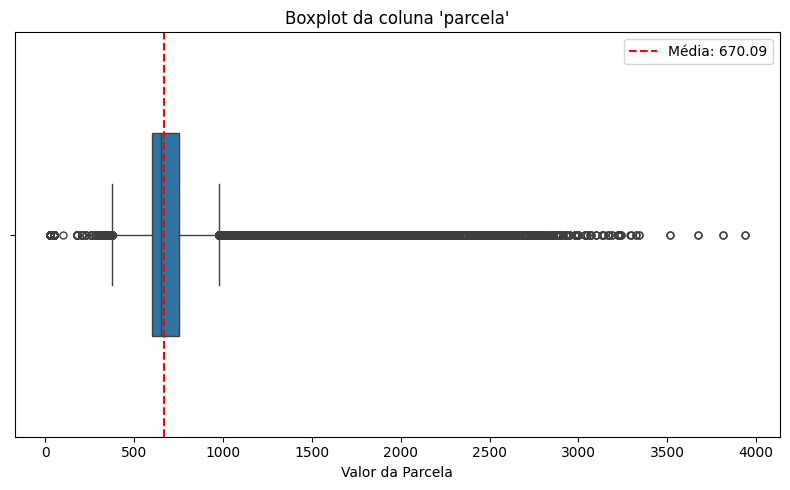

In [ ]:
#criando boxplot para mostrar outliers e outros valores:

# df_plot = df_bolsapl_lazy.select(["parcela"]).collect().to_pandas()

# plt.figure(figsize=(8,5))
# sns.boxplot(data=df_plot, x="parcela", width=0.5, fliersize=5)

# media = df_plot["parcela"].mean()
# plt.axvline(media, color='red', linestyle='--', label=f"Média: {media:.2f}")

# plt.title("Boxplot da coluna 'parcela'")
# plt.legend()
# plt.xlabel("Valor da Parcela")
# plt.tight_layout()
# plt.show()

In [55]:
#verifica os 10 maiores valores da coluna:

df_bolsapl_lazy.sort("parcela", descending=True).limit(10).collect()


mes_comp,mes_ref,uf,cod_municipio,municipio,nis,favorecido,parcela
i64,i64,str,i64,str,str,str,f64
202501,202501,"""AM""",241,"""itacoatiara""","""21218468159""","""EVERTON DA SILVA DE MELO""",3938.0
202502,202502,"""AM""",241,"""itacoatiara""","""21218468159""","""EVERTON DA SILVA DE MELO""",3938.0
202501,202501,"""AM""",207,"""autazes""","""16449789671""","""LENITA CORREIA DE MENEZES""",3814.0
202502,202502,"""AM""",207,"""autazes""","""16449789671""","""LENITA CORREIA DE MENEZES""",3814.0
202501,202501,"""GO""",9571,"""rioverde""","""21217665503""","""BERENICE REDZE""",3674.0
202502,202502,"""GO""",9571,"""rioverde""","""21217665503""","""BERENICE REDZE""",3674.0
202501,202501,"""MT""",97,"""querencia""","""23653255100""","""JOAO DE DEUS SIRVO""",3514.0
202502,202502,"""MT""",97,"""querencia""","""23653255100""","""JOAO DE DEUS SIRVO""",3514.0
202501,202501,"""GO""",9445,"""luziania""","""16580299712""","""THAYNARA FERREIRA VELOSO""",3338.0


In [56]:
#quantidade de outliers por estado:

outliers = df_bolsapl_lazy.filter(
    (pl.col("parcela") > limite_superior) | (pl.col("parcela") < limite_inferior)
)

print(
    outliers.group_by("uf").agg(
        pl.len().alias("quantidade_outliers")
    ).sort("quantidade_outliers", descending=True).collect()
)

shape: (27, 2)
┌─────┬─────────────────────┐
│ uf  ┆ quantidade_outliers │
│ --- ┆ ---                 │
│ str ┆ u32                 │
╞═════╪═════════════════════╡
│ SP  ┆ 726800              │
│ BA  ┆ 518020              │
│ MG  ┆ 460539              │
│ RJ  ┆ 377139              │
│ PA  ┆ 342673              │
│ …   ┆ …                   │
│ TO  ┆ 52283               │
│ AC  ┆ 42930               │
│ RO  ┆ 38900               │
│ AP  ┆ 34675               │
│ RR  ┆ 30705               │
└─────┴─────────────────────┘


In [57]:
# somatório de valor por beneficiário:

benef_totais_lazy = (
    df_bolsapl_lazy
    .group_by(["favorecido", "uf", "municipio"])
    .agg(
        pl.col("parcela").sum().alias("total_recebido")
    )
    .sort("total_recebido", descending=True)  
)

benef_totais_top20 = benef_totais_lazy.head().collect()

benef_totais_top20


favorecido,uf,municipio,total_recebido
str,str,str,f64
"""MARIA APARECIDA DA SILVA""","""SP""","""saopaulo""",444601.0
"""MARIA JOSE DA SILVA""","""SP""","""saopaulo""",381595.0
"""MARIA JOSE DA SILVA""","""PE""","""jaboataodosguararapes""",361988.0
"""MARIA JOSE DA SILVA""","""PE""","""caruaru""",354864.0
"""MARIA JOSE DA SILVA""","""PE""","""recife""",345583.0


In [63]:
benef_totais_lazy = (
    df_bolsapl.lazy()
    .group_by(["favorecido", "uf", "municipio", "mes_ref", "mes_comp"])
    .agg(
        pl.col("parcela").sum().alias("total_recebido")
    )
    .sort("total_recebido", descending=True)
)

# Pegar os 10 primeiros (ainda em Lazy)
benef_totais_top10_lazy = benef_totais_lazy.limit(10)


In [64]:
#comparar estados entre si em total e média de valor:

# Agrupamento por estado (uf), com soma e média
df_estados_lazy = (
    df_bolsapl_lazy
    .group_by("uf")
    .agg([
        pl.col("parcela").sum().alias("total_estado"),
        pl.col("parcela").mean().alias("media_estado")
    ])
    .sort("media_estado", descending=True)
)

# Formatação do total em milhões
df_estados_formatado = (
    df_estados_lazy
    .with_columns([
    (pl.col("total_estado") / 1_000_000).round(2).cast(pl.Utf8) + pl.lit(" mi")
    .alias("total_estado_formatado")
]))

# Mostrar os 10 primeiros
df_estados_formatado.head().limit(10).collect()


uf,total_estado,media_estado
str,str,f64
"""RR""","""116.93 mi""",737.279753
"""AM""","""931.37 mi""",727.248844
"""AC""","""188.14 mi""",718.774397
"""AP""","""174.15 mi""",717.486918
"""PA""","""1864.84 mi""",697.50517


In [ ]:
#CORRIGIR AQUI!!!

## Converte 'total_estado' no próprio lazy para float (removendo ' mi' e multiplicando)
df_estados_lazy = df_estados_lazy.with_columns([
    pl.when(pl.col("total_estado").dtype == pl.Utf8)
      .then(
          (pl.col("total_estado").str.replace(" mi", "").cast(pl.Float64) * 1_000_000)
      )
      .otherwise(pl.col("total_estado"))
      .alias("total_estado")
])

# Para o gráfico da média por estado
df_media = (
    df_estados_lazy
    .sort("media_estado", descending=True)
    .select(["uf", "media_estado"])
    .collect()
)

plt.figure(figsize=(14,7))
sns.barplot(
    data=df_media.to_pandas(),
    x="uf",
    y="media_estado",
    palette="viridis"
)
plt.title("Média Valor Recebido por Favorecido por Estado")
plt.xlabel("Estado (UF)")
plt.ylabel("Média (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Para o gráfico do total por estado (agora total_estado já é float)
df_total = (
    df_estados_lazy
    .sort("total_estado", reverse=True)
    .select(["uf", "total_estado"])
    .collect()
)

plt.figure(figsize=(14,7))
sns.barplot(
    data=df_total.to_pandas(),
    x="uf",
    y="total_estado",
    palette="magma"
)
plt.title("Total do valor recebido no Bolsa Família por estado (em milhões de R$)")
plt.xlabel("Estado (UF)")
plt.ylabel("Total (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

AttributeError: 'Expr' object has no attribute 'dtype'

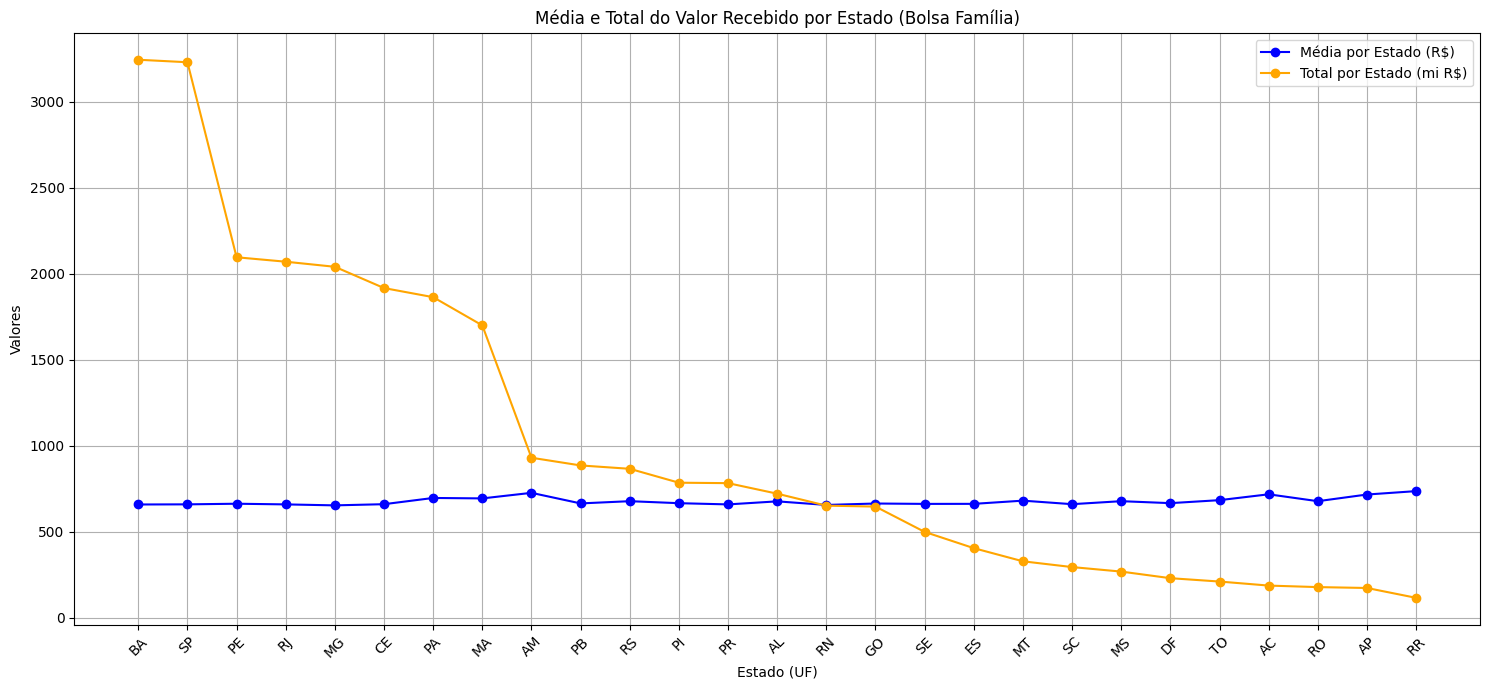

In [ ]:
# Ordena pela média em ordem decrescente e converte para pandas
df_plot = df_estados.sort("total_estado_num", descending=True).to_pandas()

plt.figure(figsize=(15, 7))

plt.plot(df_plot["uf"], df_plot["media_estado"], marker='o', label="Média por Estado (R$)", color="blue")

plt.plot(df_plot["uf"], df_plot["total_estado_num"] / 1_000_000, marker='o', label="Total por Estado (mi R$)", color="orange")

plt.title("Média e Total do Valor Recebido por Estado (Bolsa Família)")
plt.xlabel("Estado (UF)")
plt.ylabel("Valores")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()